# Setup


In [ ]:
%load_ext autoreload
%autoreload 2

import data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn import set_config
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import TweedieRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap

warnings.filterwarnings("ignore")          # keep the notebook output clean
set_config(display="diagram")              # show pipelines as diagrams
RANDOM_STATE = 9                            # group 09 (ﾉ◕ヮ◕)ﾉ*:・ﾟ✧
plt.rcParams["figure.figsize"] = (9, 4.5)
print("setup done")

pd.set_option("display.max_columns", 40)

print(data.__file__)   # should end in /data.py — if it prints None, data.py isn't beside the notebook

In [ ]:
import os, sys

print("cwd:", os.getcwd())
print("data* files here:", [f for f in os.listdir() if f.startswith("data")])

sys.modules.pop("data", None)  # drop the cached 'data = folder' from earlier
import data

print("data.__file__:", data.__file__)  # want .../data.py, NOT None

In [ ]:
if "df" not in globals():
    # downloads the parquet on the very first run, cached after
    df = data.load_raw()
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

2,721,780 rows x 30 columns


,amountPaidOnBuildingClaim,ratedFloodZone,elevationDifference,baseFloodElevation,lowestFloorElevation,lowestAdjacentGrade,elevatedBuildingIndicator,basementEnclosureCrawlspaceType,obstructionType,occupancyType,numberOfFloorsInTheInsuredBuilding,buildingDescriptionCode,condominiumCoverageTypeCode,postFIRMConstructionIndicator,originalConstructionDate,primaryResidenceIndicator,rentalPropertyIndicator,totalBuildingInsuranceCoverage,totalContentsInsuranceCoverage,buildingDeductibleCode,crsClassificationCode,elevationCertificateIndicator,state,countyCode,yearOfLoss,dateOfLoss,latitude,longitude,buildingReplacementCost,buildingPropertyValue
0,7243.04,A07,None,None,None,None,False,NaN,10.0,1.0,1.0,NaN,N,False,1970-07-01,False,False,59700.0,8800.0,1,NaN,NaN,NJ,34025,1992,1992-12-11,40.4,-74.0,0.0,24400.0
1,39008.35,AE,6.0,7.4,0.0,0.0,True,NaN,15.0,11.0,2.0,1.0,N,False,1982-01-01,False,False,250000.0,21000.0,F,NaN,NaN,FL,12037,2018,2018-10-10,29.7,-84.9,299144.0,257264.0
2,None,A17,None,None,None,None,False,2.0,10.0,1.0,2.0,NaN,N,False,1959-07-01,False,False,176000.0,50000.0,1,NaN,NaN,PA,42091,1996,1996-12-16,40.1,-75.4,NaN,NaN
3,3559.00,AE,None,None,None,None,False,NaN,10.0,1.0,1.0,NaN,N,False,1492-10-12,True,False,18300.0,0.0,0,NaN,2,MS,28109,2001,2001-06-14,30.5,-89.7,129000.0,124000.0
4,15784.20,C,None,None,None,None,False,NaN,10.0,1.0,1.0,NaN,N,False,1492-10-12,False,False,33000.0,10000.0,NaN,NaN,NaN,TX,48039,1979,1979-07-26,29.4,-95.2,0.0,53300.0


In [ ]:
schema = data.get_field_schema()  # name / type / description / key / nullable
schema.head()

,name,type,description,primaryKey,isNullable
0,asOfDate,datetime,The effective date of the data in the file. In...,False,True
1,amountPaidOnBuildingClaim,"decimal(12,2)",Dollar amount paid on the building claim. In s...,False,True
2,amountPaidOnContentsClaim,"decimal(12,2)",Dollar amount paid on the contents claim. In s...,False,True
3,amountPaidOnIncreasedCostOfComplianceClaim,"decimal(12,2)",ICC coverage is one of several flood insurance...,False,True
4,netBuildingPaymentAmount,"decimal(12,2)",Net building payment amount made to insured in...,False,True


In [ ]:
display(df.dtypes)
df.isna().mean().sort_values(ascending=False).head(20)  # sparsest columns first

amountPaidOnBuildingClaim              object
ratedFloodZone                            str
elevationDifference                    object
baseFloodElevation                     object
lowestFloorElevation                   object
lowestAdjacentGrade                    object
elevatedBuildingIndicator                bool
basementEnclosureCrawlspaceType       float64
obstructionType                       float64
occupancyType                         float64
numberOfFloorsInTheInsuredBuilding    float64
buildingDescriptionCode               float64
condominiumCoverageTypeCode               str
postFIRMConstructionIndicator            bool
originalConstructionDate               object
primaryResidenceIndicator                bool
rentalPropertyIndicator                  bool
totalBuildingInsuranceCoverage        float64
totalContentsInsuranceCoverage        float64
buildingDeductibleCode                    str
crsClassificationCode                 float64
elevationCertificateIndicator     

crsClassificationCode                 0.949849
lowestAdjacentGrade                   0.810814
elevationCertificateIndicator         0.779866
lowestFloorElevation                  0.763696
baseFloodElevation                    0.756969
elevationDifference                   0.729864
basementEnclosureCrawlspaceType       0.697886
buildingDescriptionCode               0.639162
obstructionType                       0.444430
buildingReplacementCost               0.219006
buildingPropertyValue                 0.218964
amountPaidOnBuildingClaim             0.208081
buildingDeductibleCode                0.098972
ratedFloodZone                        0.051081
countyCode                            0.022942
longitude                             0.015225
latitude                              0.015225
condominiumCoverageTypeCode           0.013760
numberOfFloorsInTheInsuredBuilding    0.006337
originalConstructionDate              0.000730
dtype: float64

count     2155429
unique    1357994
top          0.00
freq       150348
Name: amountPaidOnBuildingClaim, dtype: object
zero payouts: 0.055
negative payouts: 86


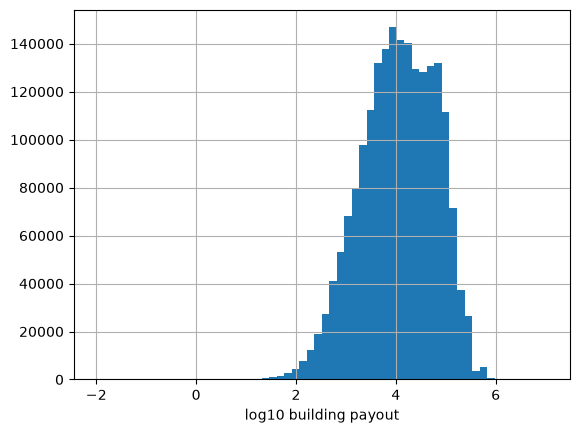

In [6]:
print(df[data.TARGET].describe())
print(
    "zero payouts:", (df[data.TARGET] == 0).mean().round(3)
)  # denied / no building payment
print("negative payouts:", (df[data.TARGET] < 0).sum())  # re-issued cheques
pos = df[df[data.TARGET] > 0][data.TARGET]
np.log10(pos).hist(bins=60)
plt.xlabel("log10 building payout")
plt.show()

In [ ]:
for col in ["elevationDifference", "baseFloodElevation"]:
    print(col, "== 9999 sentinel:", (df[col] == 9999).mean().round(3))
print(
    df["occupancyType"].value_counts().head(12)
)  # 1-digit legacy vs 2-digit Risk Rating 2.0
print(df["ratedFloodZone"].value_counts().head(12))

elevationDifference == 9999 sentinel: 0.0
baseFloodElevation == 9999 sentinel: 0.0
occupancyType
1.0     1793554
11.0     414893
4.0      170158
2.0      130077
3.0       79118
18.0      36948
15.0      24434
6.0       23703
12.0      19640
16.0      10671
14.0       9443
13.0       8207
Name: count, dtype: int64
ratedFloodZone
AE     939766
X      406706
A      201560
C      164158
B      115181
A04     51876
A01     51408
A05     48604
VE      47935
A06     47105
A08     45756
A07     43730
Name: count, dtype: int64


In [ ]:
# quick check
import os

print("Current Working Directory:", os.getcwd())

run `pip install -r requirements.txt`


In [4]:
import subprocess
import sys

# Get the exact Python executable running this notebook
python_exe = sys.executable

# Run pip freeze using this specific Python executable
result = subprocess.run(
    [python_exe, "-m", "pip", "freeze"], capture_output=True, text=True
)

# Write the output to requirements.txt
with open("requirements.txt", "w") as f:
    f.write(result.stdout)

print("> requirements.txt generated.")

> requirements.txt generated.


In [6]:
DATA_PATH = "data/raw/FimaNfipClaimsV2.parquet"  # full data
DATA_PATH = "data/sample/nfip_sample.parquet"  # representative slice
df = pd.read_parquet(DATA_PATH, engine="pyarrow")

print(f"rows: {len(df):,}   columns: {df.shape[1]}")
df.head(3)

rows: 30,660   columns: 73


,agricultureStructureIndicator,asOfDate,basementEnclosureCrawlspaceType,policyCount,crsClassificationCode,dateOfLoss,elevatedBuildingIndicator,elevationCertificateIndicator,elevationDifference,baseFloodElevation,ratedFloodZone,houseWorship,locationOfContents,lowestAdjacentGrade,lowestFloorElevation,numberOfFloorsInTheInsuredBuilding,nonProfitIndicator,obstructionType,occupancyType,originalConstructionDate,...,nonPaymentReasonContents,nonPaymentReasonBuilding,numberOfUnits,buildingReplacementCost,contentsReplacementCost,replacementCostBasis,stateOwnedIndicator,waterDepth,floodZoneCurrent,buildingDescriptionCode,rentalPropertyIndicator,state,reportedCity,reportedZipCode,countyCode,censusTract,censusBlockGroupFips,latitude,longitude,id
0,False,2026-06-01 00:00:00+00:00,2.0,1,NaN,1999-12-16,True,1,None,None,A05,False,NaN,None,None,2.0,False,60.0,1.0,1952-07-01,...,NaN,01,1.0,82236.0,NaN,A,False,0.0,NaN,NaN,False,VA,Currently Unavailable,23666,51735,51735340300,517353403001,37.1,-76.4,b'G\xde\x15o\x19ZD\xeb\xa2H(\xb4\xf1X\x0b\x9b'
1,False,2026-06-01 00:00:00+00:00,1.0,1,NaN,2008-09-12,False,NaN,None,None,AE,False,2.0,None,None,2.0,False,NaN,1.0,1955-01-01,...,NaN,NaN,1.0,98672.0,0.0,R,False,-7.0,NaN,NaN,False,IL,Currently Unavailable,60104,17031,17031817000,170318170004,41.9,-87.9,b'%\xaf$<9\xb3E\xbe\x8a\x07Z\x96\xa3o>/'
2,False,2026-06-01 00:00:00+00:00,NaN,1,NaN,1979-08-30,False,1,None,None,A,False,3.0,None,None,1.0,False,10.0,4.0,1492-10-12,...,NaN,NaN,1.0,0.0,0.0,A,False,1.0,NaN,NaN,False,PA,Currently Unavailable,17509,42071,42071014300,420710143001,40.0,-76.0,b'9\xb0w\xed\n\x80K\x99\xa0E%}\xf9\x81\x1f\x99'


In [8]:
# text -> numeric (incliing payout target)
num_coerce = [
    "amountPaidOnBuildingClaim",
    "totalBuildingInsuranceCoverage",
    "totalContentsInsuranceCoverage",
    "elevationDifference",
    "baseFloodElevation",
    "lowestFloorElevation",
    "lowestAdjacentGrade",
    "buildingReplacementCost",
    "crsClassificationCode",
    "numberOfFloorsInTheInsuredBuilding",
]
for c in num_coerce:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# elevation 'not reported' (9999 / -9999) -> NaN
for c in [
    "elevationDifference",
    "baseFloodElevation",
    "lowestFloorElevation",
    "lowestAdjacentGrade",
]:
    df.loc[df[c].abs() >= 9990, c] = np.nan

# Trim large values for building age at loss
build_year = pd.to_datetime(df["originalConstructionDate"], errors="coerce").dt.year
df["building_age"] = (df["yearOfLoss"] - build_year).where(
    lambda s: (s >= 0) & (s <= 200)
)

# deductible code -> £ amount
ded_map = {
    "0": 500,
    "1": 1000,
    "2": 2000,
    "3": 3000,
    "4": 4000,
    "5": 5000,
    "9": 750,
    "A": 10000,
    "B": 15000,
    "C": 20000,
    "D": 25000,
    "E": 50000,
    "F": 1250,
    "G": 1500,
    "H": 200,
}
df["deductible_amount"] = df["buildingDeductibleCode"].map(ded_map)

# occupancy cleaning: legacy (1-6) + Risk Rating 2.0 (11-19) -> one set of classes
occ_map = {
    1: "single_family",
    11: "single_family",
    2: "2to4_family",
    12: "2to4_family",
    3: "multi_family",
    13: "multi_family",
    4: "non_residential",
    6: "non_residential",
    18: "non_residential",
    19: "non_residential",
    14: "mobile_home",
    17: "mobile_home",
    15: "condo",
    16: "condo",
}
df["occupancy_class"] = df["occupancyType"].map(occ_map).fillna("other")


# put flood zone into risk families
def zone_family(z):
    if not isinstance(z, str) or z.strip() == "":
        return "Unknown"
    z = z.upper()
    if z.startswith("V"):
        return "V (velocity)"
    if z.startswith("A"):
        return "A (SFHA no BFE)" if z == "A" else "A (SFHA w/ BFE)"
    if z[0] in {"X", "B", "C"}:
        return "X/B/C (moderate-min)"
    if z == "D":
        return "D (undetermined)"
    return "Unknown"


df["zone_family"] = df["ratedFloodZone"].map(zone_family)

# codes cleaning RE categories.
# booleans -> 0/1
df["floors_cat"] = (
    df["numberOfFloorsInTheInsuredBuilding"]
    .astype("Int64")
    .astype("string")
    .fillna("missing")
)
df["basement_cat"] = (
    df["basementEnclosureCrawlspaceType"]
    .astype("Int64")
    .astype("string")
    .fillna("missing")
)
for b in [
    "postFIRMConstructionIndicator",
    "elevatedBuildingIndicator",
    "primaryResidenceIndicator",
]:
    df[b + "_i"] = df[b].astype("int8")

# setting up model
# Just want positive building claims (print decision log)
t = df["amountPaidOnBuildingClaim"]
print("SELECTION LOG")
print(f"  total rows      : {len(df):,}")
print(f"  positive payout : {int((t > 0).sum()):,}   <- kept (the severity model)")
print(f"  zero / denied   : {int((t == 0).sum()):,}")
print(f"  negative        : {int((t < 0).sum()):,}")
print(f"  missing         : {int(t.isna().sum()):,}")
model_df = df[t > 0].copy()
print(f"  -> modelling rows: {len(model_df):,}")

SELECTION LOG
  total rows      : 30,660
  positive payout : 22,385   <- kept (the severity model)
  zero / denied   : 1,885
  negative        : 50
  missing         : 6,340
  -> modelling rows: 22,385


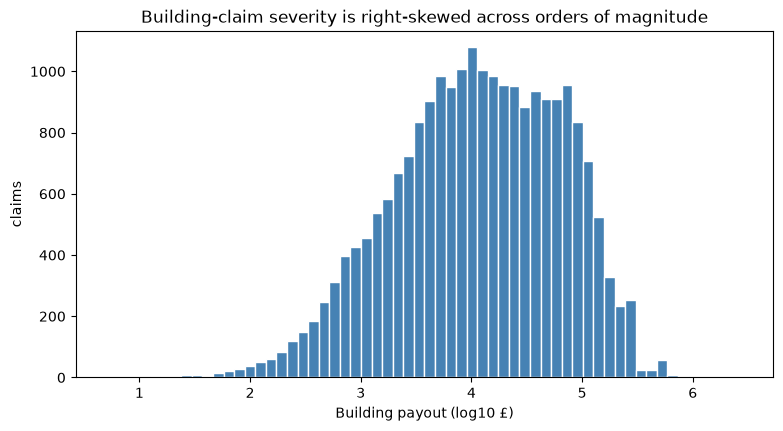

median £12,047   mean £36,313   max £2,749,032


In [10]:
# EDA
# payout distribution is right-skewed -> log-link
pos = model_df["amountPaidOnBuildingClaim"]
plt.hist(np.log10(pos), bins=60, color="steelblue", edgecolor="white")
plt.xlabel("Building payout (log10 £)")
plt.ylabel("claims")
plt.title("Building-claim severity is right-skewed across orders of magnitude")
plt.show()
print(f"median £{pos.median():,.0f}   mean £{pos.mean():,.0f}   max £{pos.max():,.0f}")

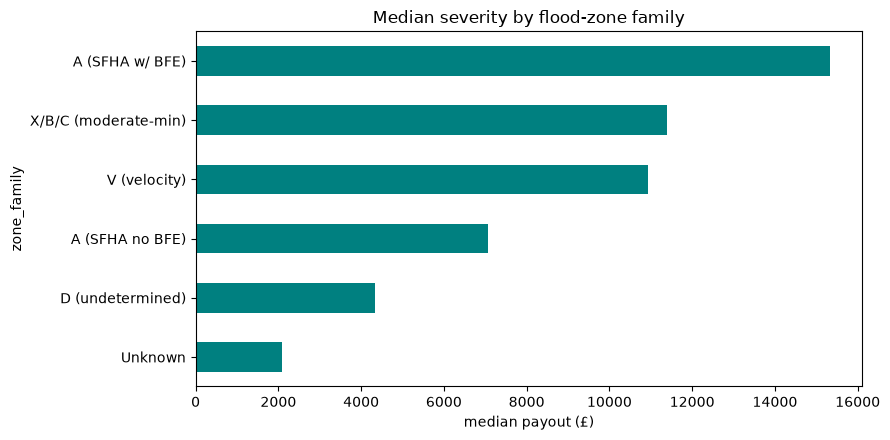

In [ ]:
# median severity by flood-zone family
# the legacy zone scheme captures *some* signal (our baseline)
order = (
    model_df.groupby("zone_family")["amountPaidOnBuildingClaim"].median().sort_values()
)
order.plot(kind="barh", color="teal")
plt.xlabel("median payout (£)")
plt.title("Median severity by flood-zone family")
plt.tight_layout()
plt.show()

# put FEMA's zone codes (A01–A30, etc.) into six buckets:
# V (velocity) - any zone starting with V.
#   Coastal high-hazard areas exposed to wave action (most dangerous)
# A (SFHA w/ BFE)
#   zones starting with A that have a specific number (A01–A30, AE, etc.)
#   Special Flood Hazard Area with a Base Flood Elevation on record
# A (SFHA no BFE)
#   bare "A" zone.
#   Special Flood Hazard Area without an established Base Flood Elevation.
# X/B/C (moderate-min)
#   zones starting with X, B, or C.
#   Moderate-to-minimal risk, outside the 100-year floodplain.
# D (undetermined)
#   zone D. Risk exists but hasn't been assessed.
# Unknown
#   blank, missing, or anything that doesn't match the above.

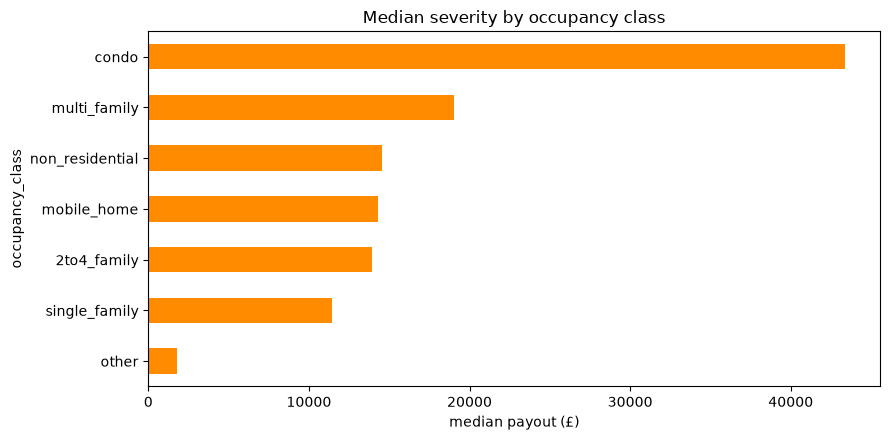

In [12]:
# occupancy class
model_df.groupby("occupancy_class")[
    "amountPaidOnBuildingClaim"
].median().sort_values().plot(kind="barh", color="darkorange")
plt.xlabel("median payout (£)")
plt.title("Median severity by occupancy class")
plt.tight_layout()
plt.show()

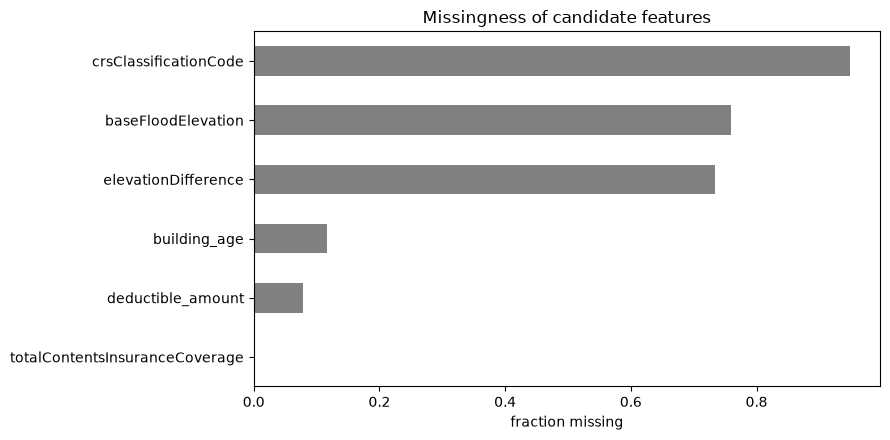

In [14]:
# how much is missing
# elevation fields mostly absent
miss = (
    model_df[
        [
            "elevationDifference",
            "baseFloodElevation",
            "building_age",
            "deductible_amount",
            "crsClassificationCode",
            "totalContentsInsuranceCoverage",
        ]
    ]
    .isna()
    .mean()
    .sort_values()
)
miss.plot(kind="barh", color="grey")
plt.xlabel("fraction missing")
plt.title("Missingness of candidate features")
plt.tight_layout()
plt.show()

In [16]:
# leakage protection
# -> undrwriting time features only (preesnt at underwriting)
# exclude everything post-flood to avoid leakage
NUMERIC = [
    "totalBuildingInsuranceCoverage",
    "totalContentsInsuranceCoverage",
    "deductible_amount",
    "building_age",
    "crsClassificationCode",
    "elevationDifference",
]
CATEG = [
    "zone_family",
    "occupancy_class",
    "state",
    "floors_cat",
    "basement_cat",
    "postFIRMConstructionIndicator_i",
    "elevatedBuildingIndicator_i",
    "primaryResidenceIndicator_i",
]
TARGET = "amountPaidOnBuildingClaim"

X = model_df[NUMERIC + CATEG].copy()
y = model_df[TARGET].astype(float).values

# excluded post-flood fields (using these would be leakage)
LEAKY = [
    "waterDepth",
    "floodWaterDuration",
    "causeOfDamage",
    "buildingDamageAmount",
    "netBuildingPaymentAmount",
    "floodEvent",
    "amountPaidOnContentsClaim",
]
print("features used   :", len(NUMERIC), "numeric +", len(CATEG), "categorical")
print("excluded (leaky):", ", ".join(LEAKY))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"\ntrain: {X_train.shape}   test: {X_test.shape}")

features used   : 6 numeric + 8 categorical
excluded (leaky): waterDepth, floodWaterDuration, causeOfDamage, buildingDamageAmount, netBuildingPaymentAmount, floodEvent, amountPaidOnContentsClaim

train: (17908, 14)   test: (4477, 14)


In [17]:
# pipeline
preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
                    ("scale", StandardScaler()),
                ]
            ),
            NUMERIC,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ),
                ]
            ),
            CATEG,
        ),
    ]
)
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

| Model                                    | Family            |
| ---------------------------------------- | ----------------- |
| **Baseline - mean payout by flood zone** | trivial heuristic |
| **GLM (Gamma, log-link)**                | linear / GLM      |
| **GBM (gradient boosting, gamma loss)**  | tree ensemble     |


In [19]:
# helpers
def rmse(a, b):
    return mean_squared_error(a, b) ** 0.5


def score_row(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE (£)": mean_absolute_error(y_true, y_pred),
        "RMSE (£)": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


# two real models (the baseline is computed directly in the next cell)
# Gamma GLM
glm = Pipeline(
    [
        ("prep", preprocess),
        ("glm", TweedieRegressor(power=2, link="log", alpha=3, max_iter=5000)),
    ]
)
gbm = Pipeline(
    [
        ("prep", preprocess),
        (
            "gbm",
            HistGradientBoostingRegressor(
                loss="gamma",
                learning_rate=0.05,
                max_iter=400,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
print("models defined")

models defined


In [22]:
results = []

# Baseline
# mean payout by rated flood zone (legacy scheme), using TRAIN only (no leakage)
zone_mean = pd.Series(y_train, index=X_train["zone_family"]).groupby(level=0).mean()
baseline_pred = X_test["zone_family"].map(zone_mean).fillna(y_train.mean()).values
results.append(score_row("Baseline (zone mean)", y_test, baseline_pred))

# GLM
glm.fit(X_train, y_train)
results.append(score_row("GLM (Gamma, log-link)", y_test, glm.predict(X_test)))
# GBM
gbm.fit(X_train, y_train)
results.append(score_row("GBM (gamma loss)", y_test, gbm.predict(X_test)))

results_df = pd.DataFrame(results).set_index("Model")
print(results_df.round(2).to_string())

                        MAE (£)  RMSE (£)    R2
Model                                          
Baseline (zone mean)   37562.68  68851.55  0.02
GLM (Gamma, log-link)  36006.02  75698.57 -0.18
GBM (gamma loss)       27999.68  58755.16  0.29


In [ ]:
# 5-fold cross-validated Mean Absolute Error
# > !not using test for tuning
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, est in [("GLM", glm), ("GBM", gbm)]:
    s = -cross_val_score(
        est, X_train, y_train, cv=cv, scoring="neg_mean_absolute_error"
    )
    print(f"CV MAE  {name}:  £{s.mean():,.0f}  ± £{s.std():,.0f}")

CV MAE  GLM:  £35,599  ± £2,065
CV MAE  GBM:  £26,701  ± £910


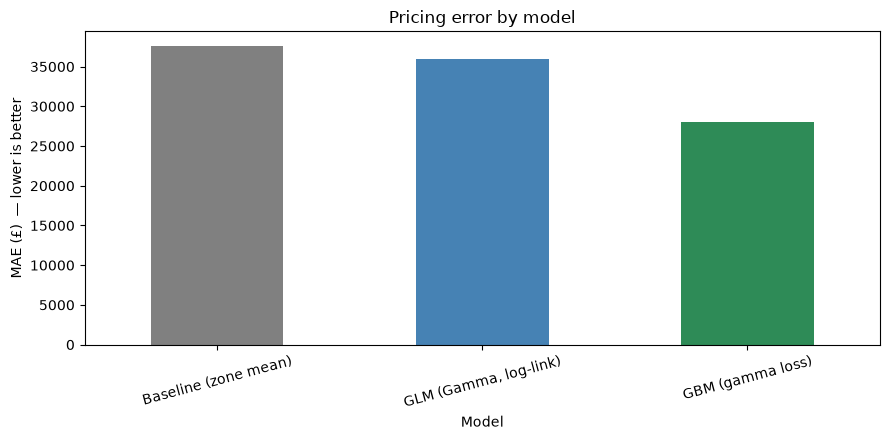

The GBM cuts average pricing error by 25% versus the legacy zone scheme.


In [24]:
# MAE by model (lower is better)
results_df["MAE (£)"].plot(kind="bar", color=["grey", "steelblue", "seagreen"])
plt.ylabel("MAE (£)  — lower is better")
plt.title("Pricing error by model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

b = results_df.loc["Baseline (zone mean)", "MAE (£)"]
g = results_df.loc["GBM (gamma loss)", "MAE (£)"]
print(
    f"The GBM cuts average pricing error by {(b-g)/b:.0%} versus the legacy zone scheme."
)

In [25]:
# tuning hte models
# GLM 
# cross-validate the regularisation strength
glm_search = GridSearchCV(
    glm, {"glm__alpha": [1, 3, 10, 30, 100]}, scoring="neg_mean_absolute_error", cv=cv
)
glm_search.fit(X_train, y_train)
print("GLM best alpha:", glm_search.best_params_["glm__alpha"])

# GBM
# small randomised search
gbm_search = RandomizedSearchCV(
    gbm,
    {
        "gbm__learning_rate": [0.03, 0.05, 0.1],
        "gbm__max_leaf_nodes": [15, 31, 63],
        "gbm__max_iter": [300, 500],
        "gbm__l2_regularization": [0.0, 1.0, 10.0],
        "gbm__min_samples_leaf": [20, 50, 100],
    },
    n_iter=12,
    scoring="neg_mean_absolute_error",
    cv=cv,
    random_state=RANDOM_STATE,
)
gbm_search.fit(X_train, y_train)
print(
    "GBM best params:",
    {k.replace("gbm__", ""): v for k, v in gbm_search.best_params_.items()},
)

# refresh the scoreboard with the tuned models
tuned = [
    score_row("Baseline (zone mean)", y_test, baseline_pred),
    score_row("GLM (tuned)", y_test, glm_search.predict(X_test)),
    score_row("GBM (tuned)", y_test, gbm_search.predict(X_test)),
]
tuned_df = pd.DataFrame(tuned).set_index("Model")
print("\n", tuned_df.round(3).to_string())
best_model = gbm_search.best_estimator_  # used for interpretation and pricing below

GLM best alpha: 3
GBM best params: {'min_samples_leaf': 50, 'max_leaf_nodes': 63, 'max_iter': 500, 'learning_rate': 0.1, 'l2_regularization': 1.0}

                         MAE (£)   RMSE (£)     R2
Model                                            
Baseline (zone mean)  37562.675  68851.553  0.023
GLM (tuned)           36006.023  75698.567 -0.181
GBM (tuned)           27683.315  58565.313  0.293


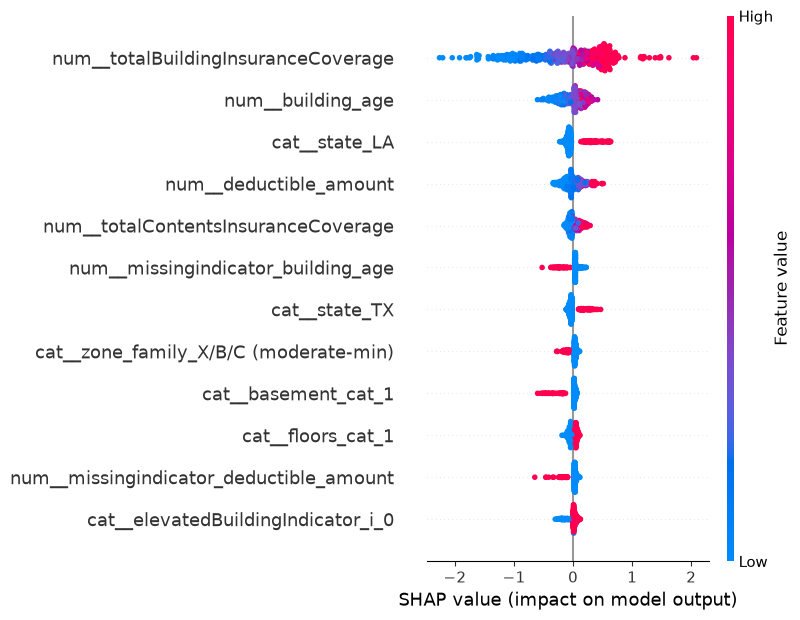

In [26]:
# sample of the training rows for speed.
Xt = best_model.named_steps["prep"].transform(X_train)
feature_names = best_model.named_steps["prep"].get_feature_names_out()
explainer = shap.TreeExplainer(best_model.named_steps["gbm"])
shap_values = explainer.shap_values(Xt[:500])
shap.summary_plot(
    shap_values, Xt[:500], feature_names=feature_names, show=True, max_display=12
)

In [ ]:
# Get importance ranking
# mean absolute SHAP value 
importance = (
    pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)
    .sort_values(ascending=False)
    .head(10)
)
print("Top drivers (mean |SHAP|):")
print(importance.to_string())

Top drivers (mean |SHAP|):
num__totalBuildingInsuranceCoverage      0.544643
num__building_age                        0.151850
cat__state_LA                            0.126762
num__deductible_amount                   0.118253
num__totalContentsInsuranceCoverage      0.070394
num__missingindicator_building_age       0.069771
cat__state_TX                            0.068641
cat__zone_family_X/B/C (moderate-min)    0.053497
cat__basement_cat_1                      0.053299
cat__floors_cat_1                        0.049567


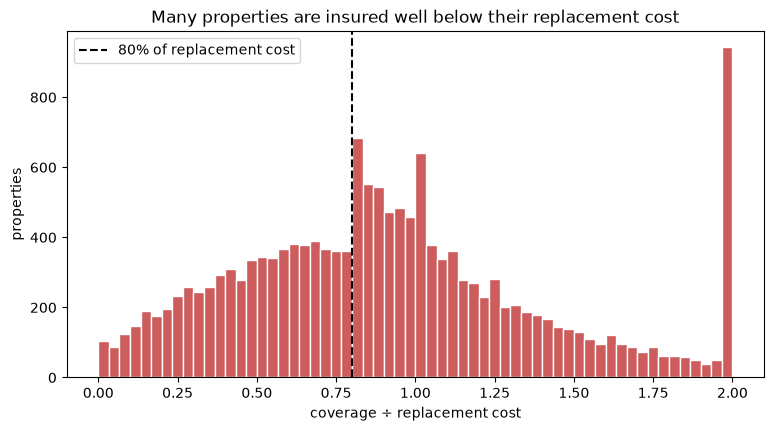

properties assessed       : 15,778
median coverage/replacement: 0.88
under-insured (<80%)       : 41%
severely under-insured(<50%): 20%


In [28]:
# behaviour explore
# coverage vs replacement cost - just where both are present
rc = pd.to_numeric(model_df["buildingReplacementCost"], errors="coerce")
cov = model_df["totalBuildingInsuranceCoverage"]
ok = rc.notna() & cov.notna() & (rc > 0)
ratio = (cov[ok] / rc[ok]).clip(upper=2)  # coverage as a fraction of replacement cost

plt.hist(ratio, bins=60, color="indianred", edgecolor="white")
plt.axvline(0.8, color="black", ls="--", label="80% of replacement cost")
plt.xlabel("coverage ÷ replacement cost")
plt.ylabel("properties")
plt.legend()
plt.title("Many properties are insured well below their replacement cost")
plt.show()

print(f"properties assessed       : {int(ok.sum()):,}")
print(f"median coverage/replacement: {ratio.median():.2f}")
print(f"under-insured (<80%)       : {(ratio < 0.8).mean():.0%}")
print(f"severely under-insured(<50%): {(ratio < 0.5).mean():.0%}")

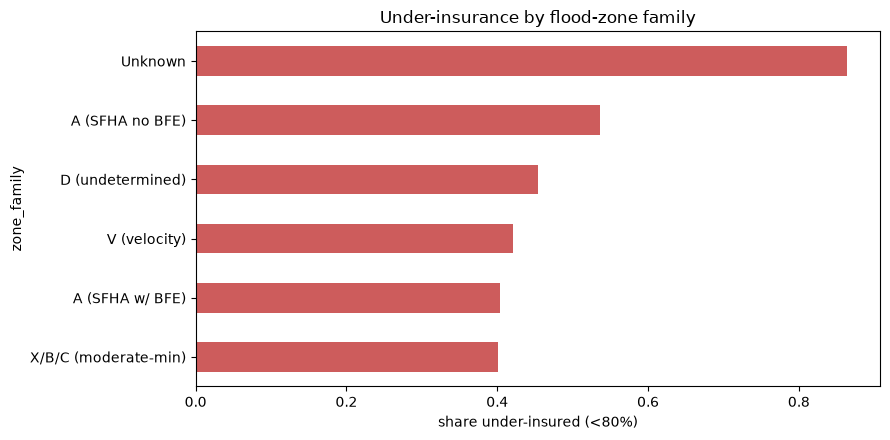

In [29]:
# Which segments are most under-insured? (share below 80% of replacement cost, by flood zone)
seg = (ratio < 0.8).groupby(model_df.loc[ok, "zone_family"]).mean().sort_values()
seg.plot(kind="barh", color="indianred")
plt.xlabel("share under-insured (<80%)")
plt.title("Under-insurance by flood-zone family")
plt.tight_layout()
plt.show()

In [30]:
# Model-implied severity for every modelled property, vs the flat zone-average it is priced at today
model_df = model_df.copy()
model_df["pred_severity"] = best_model.predict(X)

# Focus on the largest zone and show the within-zone spread the flat rate ignores
zone = model_df["zone_family"].value_counts().idxmax()
sub = model_df[model_df["zone_family"] == zone]
zone_flat = sub[
    "amountPaidOnBuildingClaim"
].mean()  # what flat zone pricing charges everyone here
deciles = sub["pred_severity"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(0)

print(f"Largest zone: {zone}  (flat zone severity = £{zone_flat:,.0f})")
print("Model-implied severity within this zone (deciles):")
print(deciles.to_string())
rel = deciles / zone_flat
print("\nImplied relativity to the flat zone rate:")
print(rel.round(2).to_string())
print(
    f"\n=> Within a single zone, the model says the top-decile risk should pay about "
    f"{rel.loc[0.9]:.1f}x what the bottom-decile risk pays — differentiation the flat rate misses."
)

Largest zone: A (SFHA w/ BFE)  (flat zone severity = £42,260)
Model-implied severity within this zone (deciles):
0.10     6884.0
0.25    12825.0
0.50    26698.0
0.75    53689.0
0.90    86238.0

Implied relativity to the flat zone rate:
0.10    0.16
0.25    0.30
0.50    0.63
0.75    1.27
0.90    2.04

=> Within a single zone, the model says the top-decile risk should pay about 2.0x what the bottom-decile risk pays — differentiation the flat rate misses.
